
# Convolution Layer Basics

This notebook demonstrates how 2D convolutions work without building a full CNN.

What you'll see:
- Create a synthetic grayscale image (white square on black background)
- Apply hand-crafted filters with `nn.Conv2d` for edge detection

In [43]:
# import necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

def show(img, title=None, cmap='gray'):
    plt.imshow(img, cmap=cmap, vmin=0, vmax=1)
    if title: plt.title(title)

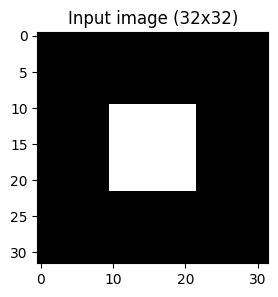

In [44]:

# Create a 32x32 grayscale image with a centered white square
H = W = 32
img = torch.zeros((1, 1, H, W), dtype=torch.float32)  # (N=1, C=1, H, W)
# white square from (10:22, 10:22)
img[:, :, 10:22, 10:22] = 1.0

plt.figure(figsize=(3,3))
show(img.squeeze().numpy(), title='Input image (32x32)')


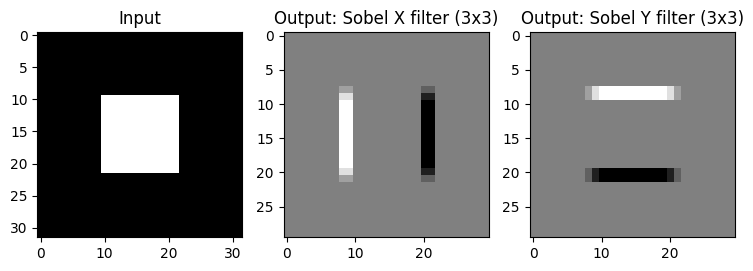

In [45]:

# Define a single Conv2d (1 input channel -> 1 output channel), 3x3 kernel
conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, bias=False)

# Use a simple edge-detection kernel (Sobel-X)
kernel = torch.tensor([[-1.,0.,1.],
                       [-2.,0.,2.],
                       [-1.,0.,1.]], dtype=torch.float32)
kernel = kernel.view(1, 1, 3, 3)  # (out_channels, in_channels, kernel height, kernel width)
with torch.no_grad():
    conv.weight.copy_(kernel) # set the weights of the conv layer to our kernel

# Apply convolution
y = conv(img)  

# Try another edge-detection kernel (Sobel-Y)
kernel2 = torch.tensor([[-1.,-2.,-1.],
                       [0.,0.,0.],
                       [1.,2.,1.]], dtype=torch.float32)
kernel2 = kernel2.view(1, 1, 3, 3)  # (out_channels, in_channels, kernel height, kernel width)
with torch.no_grad():
    conv.weight.copy_(kernel2) # set the weights of the conv layer to our kernel

# Apply convolution
y2 = conv(img)  

# Visualize output
y = (y - y.min()) / (y.max() - y.min())  # normalize to [0,1] for better visualization
y2 = (y2 - y2.min()) / (y2.max() - y2.min())  
y = y.detach().squeeze().numpy() # numpy format
y2 = y2.detach().squeeze().numpy()
plt.figure(figsize=(9,3))
plt.subplot(1,3,1)
show(img.squeeze().numpy(), title='Input')
plt.subplot(1,3,2)
show(y, title='Output: Sobel X filter (3x3)')
plt.subplot(1,3,3)
show(y2, title='Output: Sobel Y filter (3x3)')


## Summary

- Convolution slides a kernel across the image to produce a feature map.
- Kernels can detect different features, for example edges/orientations (e.g., Sobel filters).